# Sentiment Analysis on Social Media — NLP Course Project
### Group 11 | IE University | Leena El Earq · Blanca Valdes · Jaime Paz · Maximilliano Martin · Omar El Haj

This notebook is a complete walkthrough of our project. It loads all pre-computed results, saved models, and generated plots without re-running training or evaluation. Everything is reproducible by running the pipeline scripts in order:

```
python feature_extraction.py
python train_models.py
python relabel_disaster.py
python evaluate_models.py
python error_analysis.py
```

**Project goal:** Study how well Transformer-based sentiment models perform on social media text, and how robust they are when the topic changes (domain shift).

## 1. Setup & Imports

In [1]:
import json
import pickle
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.sparse import load_npz

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.4f}".format)
%matplotlib inline

ROOT = Path(".")
print("Working directory:", ROOT.resolve())
print("Plots available  :", sorted(p.name for p in (ROOT / "data/plots").iterdir()))

Working directory: /Users/leenabarq/nlp-project
Plots available  : ['accuracy_comparison_general_vs_domain.png', 'confusion_matrix_logistic_regression_domain_shift_test.png', 'confusion_matrix_logistic_regression_general_test.png', 'confusion_matrix_twitter_roberta_domain_shift_test.png', 'confusion_matrix_twitter_roberta_general_test.png', 'error_category_distribution.png', 'f1_score_per_class_logistic_regression.png', 'f1_score_per_class_twitter_roberta.png']


## 2. Dataset Statistics

We use two datasets:
- **TweetEval sentiment** (general tweets) — 3 classes: positive, negative, neutral. Source: Cardiff NLP via Hugging Face.
- **Disaster tweets** — out-of-domain test set for domain shift evaluation, originally a topic-classification corpus. Sentiment labels were assigned using **VADER** (rule-based, independent of our trained models) since the original corpus labeled all tweets as "neutral".

In [2]:
with open(ROOT / "data/reports/data_statistics.json") as f:
    data_stats = json.load(f)

rows = []
for s in data_stats["splits"]:
    dist = s["class_distribution"]
    rows.append({
        "Split": s["split"],
        "Total Rows": f"{s['total_rows']:,}",
        "Avg Length (tokens)": s["avg_tweet_length"],
        "Negative": dist.get("negative", 0),
        "Neutral": dist.get("neutral", 0),
        "Positive": dist.get("positive", 0),
        "VADER Re-labeled": "✓" if s.get("vader_relabeled") else "",
    })

stats_df = pd.DataFrame(rows)
display(stats_df.set_index("Split"))
print(f"\nTotal general training data : {data_stats['total_general_training_data']:,}")
print(f"Total domain-shift test data: {data_stats['total_domain_shift_test_data']:,}")

,Total Rows,Avg Length (tokens),Negative,Neutral,Positive,VADER Re-labeled
Split,,,,,,
train,"41,899",18.3000,7962,19217,14720,
validation,"8,979",18.4000,1706,4119,3154,
test_general,"8,979",18.4000,1706,4118,3155,
test_domain_shift,"20,931",22.7000,6733,5798,8400,✓



Total general training data : 50,878
Total domain-shift test data: 20,931


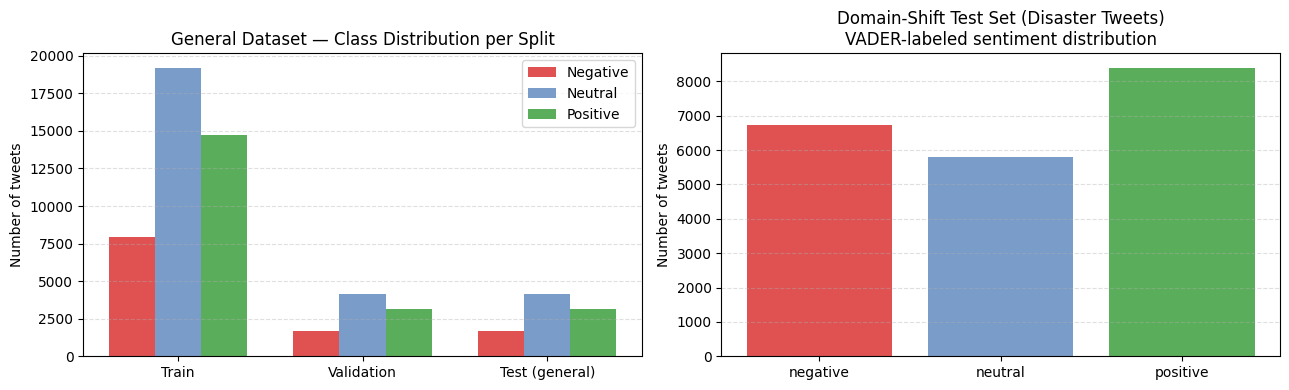

In [3]:
# Class distribution bar charts
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
labels_order = ["negative", "neutral", "positive"]
colors = ["#e05252", "#7a9cc9", "#5aad5a"]
split_data = {s["split"]: s["class_distribution"] for s in data_stats["splits"]}

# General splits
general_splits = ["train", "validation", "test_general"]
x = np.arange(len(general_splits))
width = 0.25
for i, lbl in enumerate(labels_order):
    vals = [split_data[s].get(lbl, 0) for s in general_splits]
    axes[0].bar(x + i * width, vals, width, label=lbl.capitalize(), color=colors[i])
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(["Train", "Validation", "Test (general)"])
axes[0].set_ylabel("Number of tweets")
axes[0].set_title("General Dataset — Class Distribution per Split")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Domain shift
ds_dist = split_data["test_domain_shift"]
axes[1].bar(labels_order, [ds_dist.get(l, 0) for l in labels_order], color=colors)
axes[1].set_ylabel("Number of tweets")
axes[1].set_title("Domain-Shift Test Set (Disaster Tweets)\nVADER-labeled sentiment distribution")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()

## 3. Raw Data Preview

In [4]:
train_df = pd.read_csv(ROOT / "data/train/tweets_general_train.csv")
print(f"Training set: {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
display(train_df.sample(8, random_state=42)[["text", "sentiment"]].reset_index(drop=True))

Training set: 41,899 rows × 3 columns


,text,sentiment
0,"""We may look at the Protestant vs Catholic unrest as silly, but the same is happening now against Muslims. Reign BeO...",neutral
1,"""Going town tomorrow, definitely going to HMV and buying Chapman Square. :D <USER> <3""",positive
2,May or may not be going to see Magic Mike XXL for the second time tonight . noshame,positive
3,<USER> They are great aren't they - I have one from the Ant-Man wave coming tomorrow as I want to build the Ultron f...,positive
4,....which unfortunately didn't happen but India's Dawood funded ecosystem is trying its best to 2nd guess the judici...,neutral
5,Dennison: Our offense will have its hands full with Mario Williams on Sunday.,neutral
6,1. Noel Fielding comedy gala tonight :) 2. Work all day tomorrow 3. Granny Smith festival that night,positive
7,What Would Derek Fisher Bring to the L.A. Lakers?: The Lakers may soon be creating a new position for free age...,positive


In [5]:
disaster_df = pd.read_csv(ROOT / "data/test_domain_shift/tweets_disaster.csv")
print(f"Domain-shift test set: {disaster_df.shape[0]:,} rows")
print(f"Sentiment distribution (VADER-labeled):\n{disaster_df['sentiment'].value_counts().to_string()}\n")
display(disaster_df.sample(6, random_state=7)[["text", "sentiment"]].reset_index(drop=True))

Domain-shift test set: 20,931 rows
Sentiment distribution (VADER-labeled):
sentiment
positive    8400
negative    6733
neutral     5798



,text,sentiment
0,"- The final delivery of rainwater harvesting kits has been completed for the 79 islands targeted by the project, alt...",negative
1,A record-breaking heat wave during June in central Russia caused more than 100 deaths and started huge fires.,positive
2,"Please,Where is the Senegal Embassy?",neutral
3,"The two MUJAO suicide attackers were the only fatalities in the explosions, although one soldier was lightly wounded...",negative
4,"Government sources however noted that domestic intelligence and security arrangements, in the capital and elsewhere ...",negative
5,Residents of 'unsafe areas' face a double threat: lack of safety and possible forced eviction.,negative


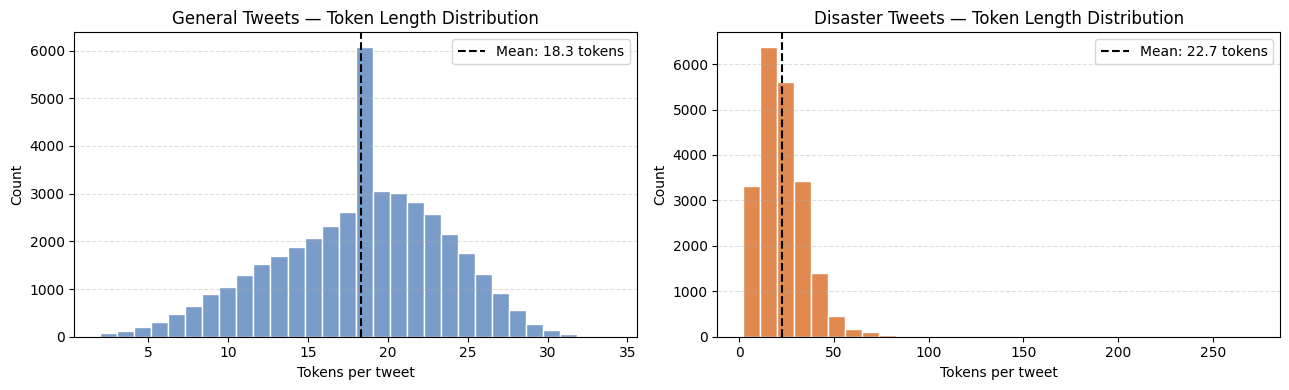

In [6]:
# Tweet length distribution — general vs disaster
train_df["token_count"] = train_df["text"].fillna("").str.split().str.len()
disaster_df["token_count"] = disaster_df["text"].fillna("").str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, df, title, color in zip(
    axes,
    [train_df, disaster_df],
    ["General Tweets — Token Length Distribution", "Disaster Tweets — Token Length Distribution"],
    ["#7a9cc9", "#e08a52"],
):
    ax.hist(df["token_count"], bins=30, color=color, edgecolor="white")
    ax.axvline(df["token_count"].mean(), color="black", linestyle="--",
               label=f"Mean: {df['token_count'].mean():.1f} tokens")
    ax.set_xlabel("Tokens per tweet")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

## 4. Feature Extraction Summary

Each tweet is represented as a combined feature vector:
- **TF-IDF** (unigrams + bigrams, vocabulary capped at 50,000 features) — fitted **exclusively on the training set** to prevent data leakage
- **5 handcrafted features:** emoji count, `!` count, `?` count, ALL-CAPS word count, total token count

These are concatenated into a single sparse matrix per split and saved under `data/features/`.

In [7]:
with open(ROOT / "data/reports/feature_report.json") as f:
    feat_report = json.load(f)

print(f"TF-IDF vocabulary size : {feat_report['vocabulary_size']:,}")
print(f"N-gram range           : {feat_report['tfidf_config']['ngram_range']}")
print(f"Max features           : {feat_report['tfidf_config']['max_features']:,}")
print()

feat_rows = []
for split_name, info in feat_report["splits"].items():
    feat_rows.append({
        "Split": split_name,
        "Rows": f"{info['rows']:,}",
        "Columns (TF-IDF + 5)": info["cols"],
        "Non-zero entries": f"{info['nnz']:,}",
        "Density": f"{info['density']:.6f}",
    })
display(pd.DataFrame(feat_rows).set_index("Split"))

# Verify shapes match CSVs
print("\nFeature matrix shapes loaded from disk:")
for name, path in [("X_train","X_train"), ("X_val","X_val"), ("X_test","X_test"), ("X_domain_shift","X_domain_shift")]:
    m = load_npz(ROOT / "data/features" / f"{path}.npz")
    print(f"  {name}: {m.shape}, nnz={m.nnz:,}")

TF-IDF vocabulary size : 50,000
N-gram range           : [1, 2]
Max features           : 50,000



,Rows,Columns (TF-IDF + 5),Non-zero entries,Density
Split,,,,
train,"41,899",50005,"1,064,543",0.000508
val,"8,979",50005,"219,333",0.000488
test,"8,979",50005,"219,972",0.000490
domain_shift,"20,931",50005,"480,697",0.000459



Feature matrix shapes loaded from disk:
  X_train: (41899, 50005), nnz=1,064,543
  X_val: (8979, 50005), nnz=219,333
  X_test: (8979, 50005), nnz=219,972
  X_domain_shift: (20931, 50005), nnz=480,697


In [8]:
# Handcrafted feature stats
hand_stats = feat_report["splits"]["train"]["handcrafted_stats"]
hf_df = pd.DataFrame(hand_stats).T.rename(columns=str.title)
print("Handcrafted feature statistics on training set:")
display(hf_df)

Handcrafted feature statistics on training set:


,Mean,Std,Min,Max
emoji_count,0.0172,0.1671,0.0000,12.0000
exclamation_count,0.3344,0.9632,0.0000,35.0000
question_count,0.1567,0.5190,0.0000,21.0000
all_caps_word_count,0.9569,1.5146,0.0000,26.0000
text_length_tokens,18.8697,5.6102,2.0000,38.0000


## 5. Saved Model Artifacts

### Model 1 — Logistic Regression (TF-IDF baseline)

In [9]:
with open(ROOT / "models/logreg_tfidf.pkl", "rb") as f:
    logreg = pickle.load(f)

with open(ROOT / "data/reports/training_history.json") as f:
    history = json.load(f)

print(f"Model type      : {type(logreg).__name__}")
print(f"Input features  : {logreg.n_features_in_:,}  (50,000 TF-IDF + 5 handcrafted)")
print(f"Classes         : {list(logreg.classes_)}")
print(f"Solver          : {logreg.solver}")
print(f"Max iterations  : {logreg.max_iter}")
print(f"Regularisation  : L2 (default C=1.0)")
print(f"\nValidation accuracy: {history['logistic_regression']['validation_accuracy']:.4f}")

Model type      : LogisticRegression
Input features  : 50,005  (50,000 TF-IDF + 5 handcrafted)
Classes         : [np.int64(0), np.int64(1), np.int64(2)]
Solver          : lbfgs
Max iterations  : 5000
Regularisation  : L2 (default C=1.0)

Validation accuracy: 0.6512


### Model 2 — Twitter-RoBERTa (fine-tuned Transformer)

Base model: `cardiffnlp/twitter-roberta-base-sentiment-latest` — a RoBERTa model pre-trained on 124M tweets and fine-tuned for sentiment. We further fine-tune it on our training set for 1 epoch (5,000-sample subset due to CPU constraints).

In [10]:
roberta_dir = ROOT / "models/twitter_roberta_sentiment"
with open(roberta_dir / "config.json") as f:
    roberta_cfg = json.load(f)

print(f"Base model      : {roberta_cfg.get('_name_or_path', 'cardiffnlp/twitter-roberta-base-sentiment-latest')}")
print(f"Architecture    : {roberta_cfg.get('model_type', 'roberta')}")
print(f"Hidden size     : {roberta_cfg.get('hidden_size')}")
print(f"Attention heads : {roberta_cfg.get('num_attention_heads')}")
print(f"Hidden layers   : {roberta_cfg.get('num_hidden_layers')}")
print(f"Vocab size      : {roberta_cfg.get('vocab_size'):,}")
print(f"Label mapping   : {roberta_cfg.get('id2label')}")

tr = history["twitter_roberta"]
print(f"\nFine-tuning config:")
print(f"  Epochs        : {tr['epochs']}  (1 epoch, 5,000-sample subset — CPU constraint)")
print(f"  Batch size    : {tr['batch_size']}")
print(f"  Learning rate : {tr['learning_rate']}")
print(f"  Device        : {tr['device']}")
print(f"\nTraining history:")
for ep in tr["history"]:
    print(f"  Epoch {ep['epoch']}: train_loss={ep['train_loss']:.4f}  val_loss={ep['val_loss']:.4f}  val_acc={ep['val_accuracy']:.4f}")

Base model      : cardiffnlp/twitter-roberta-base-sentiment-latest
Architecture    : roberta
Hidden size     : 768
Attention heads : 12
Hidden layers   : 12
Vocab size      : 50,265
Label mapping   : {'0': 'negative', '1': 'neutral', '2': 'positive'}

Fine-tuning config:
  Epochs        : 1  (1 epoch, 5,000-sample subset — CPU constraint)
  Batch size    : 16
  Learning rate : 2e-05
  Device        : cpu

Training history:
  Epoch 1: train_loss=0.5837  val_loss=0.5296  val_acc=0.7670


## 6. Evaluation Results

Both models are evaluated on:
- **General test set** — 8,979 tweets, in-domain (same distribution as training)
- **Domain-shift test set** — 20,931 disaster tweets, out-of-domain

The *majority baseline* (always predicting "neutral") is included as a sanity check.

In [11]:
with open(ROOT / "data/reports/evaluation_results.json") as f:
    eval_results = json.load(f)

model_keys = [k for k in eval_results if k != "label_mapping"]
rows = []
for mkey in model_keys:
    for split, split_label in [("general_test", "General Test"), ("domain_shift_test", "Domain Shift")]:
        m = eval_results[mkey][split]
        rows.append({
            "Model": mkey.replace("_", " ").title(),
            "Test Set": split_label,
            "Accuracy": m["accuracy"],
            "Majority Baseline": m["majority_baseline_accuracy"],
            "Macro Precision": m["macro"]["precision"],
            "Macro Recall": m["macro"]["recall"],
            "Macro F1": m["macro"]["f1"],
            "Weighted F1": m["weighted"]["f1"],
        })

summary_df = pd.DataFrame(rows).set_index(["Model", "Test Set"])
display(summary_df)

Accuracy  Majority Baseline  \
Model               Test Set                                    
Logistic Regression General Test    0.6697             0.4586   
                    Domain Shift    0.4343             0.4013   
Twitter Roberta     General Test    0.7590             0.4586   
                    Domain Shift    0.4750             0.4013   

                                  Macro Precision  Macro Recall  Macro F1  \
Model               Test Set                                                
Logistic Regression General Test           0.6740        0.6205    0.6359   
                    Domain Shift           0.5599        0.4731    0.4172   
Twitter Roberta     General Test           0.7555        0.7533    0.7544   
                    Domain Shift           0.6378        0.5186    0.4559   

                                  Weighted F1  
Model               Test Set                   
Logistic Regression General Test       0.6630  
                    Domain Shift       0.4058  
Twitter Roberta     General Test       0.7589  
                    Domain Shift       0.4389

In [12]:
# Per-class F1 breakdown
print("Per-class F1 scores\n" + "=" * 65)
for mkey in model_keys:
    for split, split_label in [("general_test", "General Test"), ("domain_shift_test", "Domain Shift")]:
        m = eval_results[mkey][split]
        print(f"\n  {mkey.replace('_', ' ').title()} — {split_label}")
        per_df = pd.DataFrame(m["per_class"]).T[["precision", "recall", "f1", "support"]]
        display(per_df)

Per-class F1 scores

  Logistic Regression — General Test


,precision,recall,f1,support
negative,0.6581,0.4185,0.5116,1706.0000
neutral,0.6411,0.7751,0.7018,4118.0000
positive,0.7228,0.6678,0.6942,3155.0000



  Logistic Regression — Domain Shift


,precision,recall,f1,support
negative,0.5555,0.3740,0.4470,6733.0000
neutral,0.3445,0.8482,0.4900,5798.0000
positive,0.7796,0.1970,0.3145,8400.0000



  Twitter Roberta — General Test


,precision,recall,f1,support
negative,0.7294,0.7157,0.7225,1706.0000
neutral,0.7472,0.7499,0.7485,4118.0000
positive,0.7900,0.7943,0.7922,3155.0000



  Twitter Roberta — Domain Shift


,precision,recall,f1,support
negative,0.6566,0.5482,0.5975,6733.0000
neutral,0.3561,0.8499,0.5019,5798.0000
positive,0.9007,0.1576,0.2683,8400.0000


## 7. Plots — Accuracy, Confusion Matrices, Per-Class F1

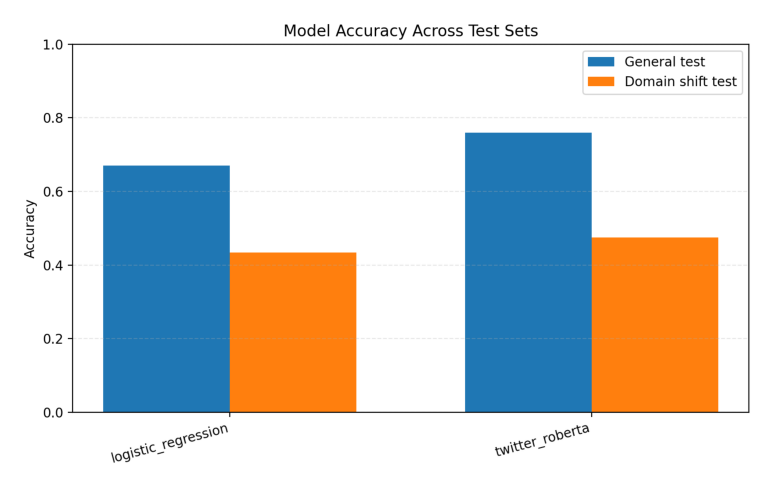

In [13]:
img = mpimg.imread(ROOT / "data/plots/accuracy_comparison_general_vs_domain.png")
fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

Matplotlib is building the font cache; this may take a moment.


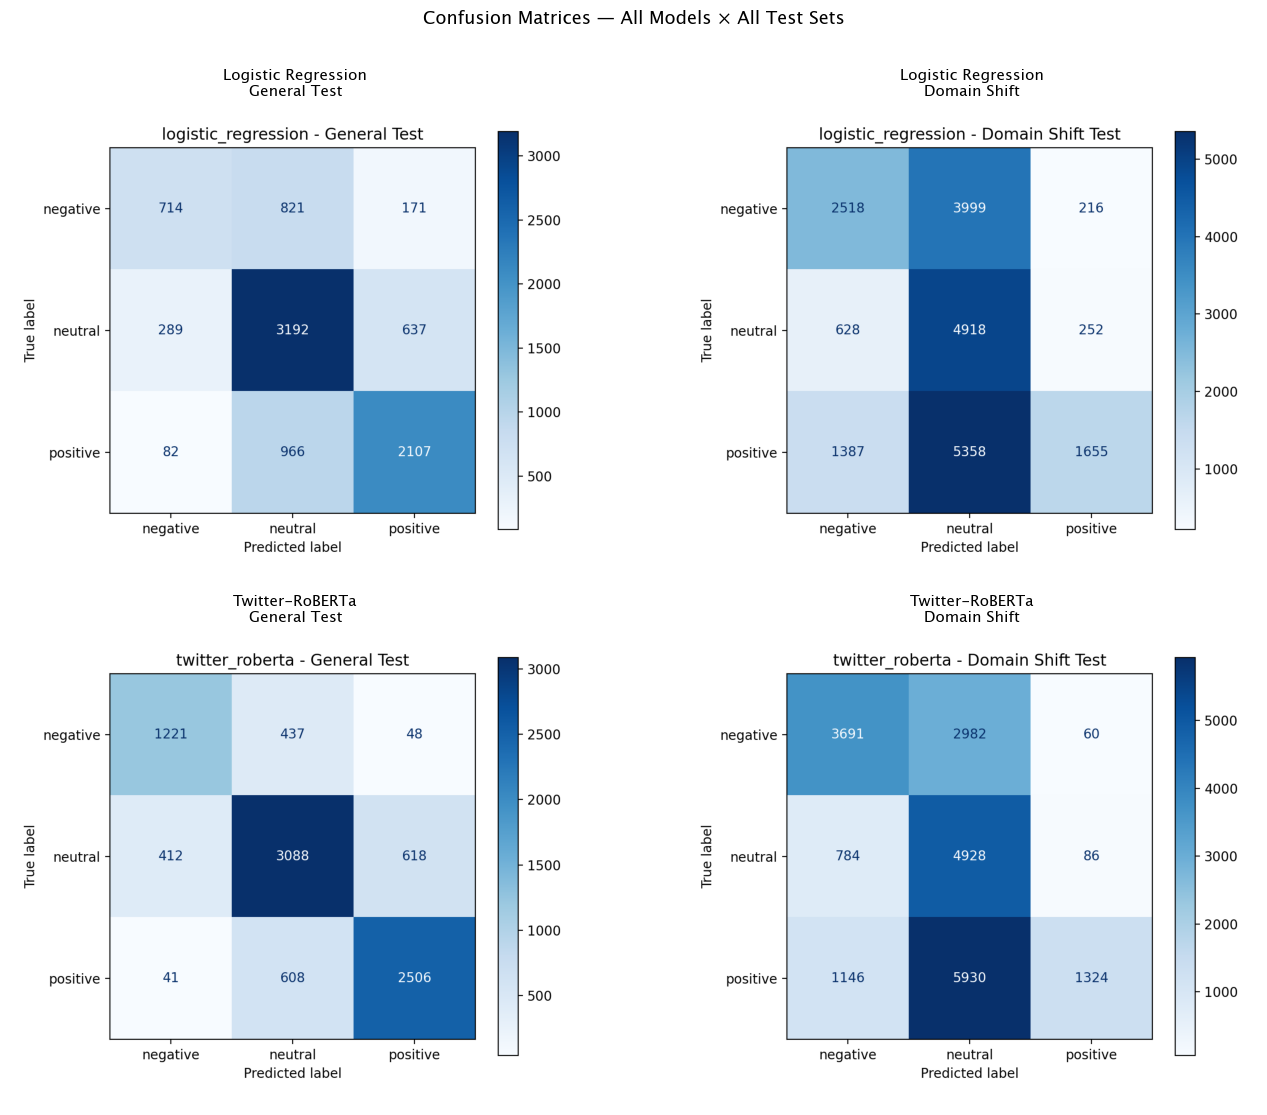

In [14]:
# 2×2 confusion matrix grid
cm_files = [
    ("confusion_matrix_logistic_regression_general_test.png",      "Logistic Regression\nGeneral Test"),
    ("confusion_matrix_logistic_regression_domain_shift_test.png", "Logistic Regression\nDomain Shift"),
    ("confusion_matrix_twitter_roberta_general_test.png",          "Twitter-RoBERTa\nGeneral Test"),
    ("confusion_matrix_twitter_roberta_domain_shift_test.png",     "Twitter-RoBERTa\nDomain Shift"),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (fname, title) in zip(axes.flat, cm_files):
    ax.imshow(mpimg.imread(ROOT / "data/plots" / fname))
    ax.axis("off")
    ax.set_title(title, fontsize=11, pad=6)
fig.suptitle("Confusion Matrices — All Models × All Test Sets", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

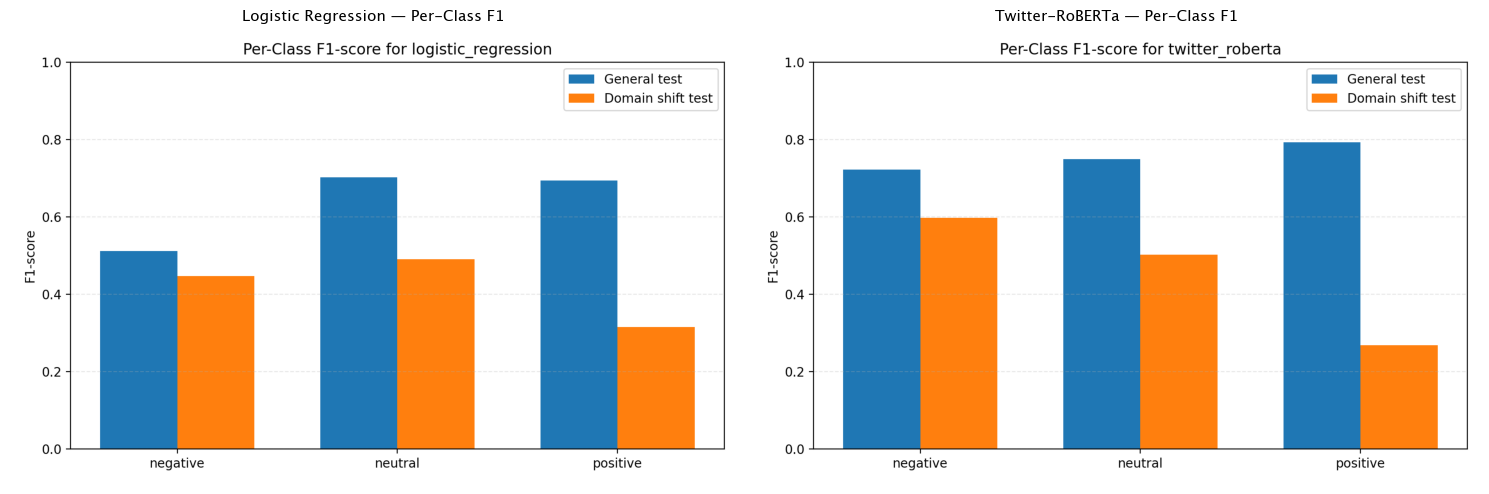

In [15]:
# Per-class F1 plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, fname, title in zip(axes,
    ["f1_score_per_class_logistic_regression.png", "f1_score_per_class_twitter_roberta.png"],
    ["Logistic Regression — Per-Class F1", "Twitter-RoBERTa — Per-Class F1"],
):
    ax.imshow(mpimg.imread(ROOT / "data/plots" / fname))
    ax.axis("off")
    ax.set_title(title, fontsize=11, pad=6)
fig.tight_layout()
plt.show()

### Key Observations

1. **RoBERTa clearly outperforms Logistic Regression** on general tweets: 75.9% vs 67.0% accuracy (+8.9 pp), 0.754 vs 0.636 macro F1. Contextual representations capture sentiment nuance that TF-IDF bag-of-words misses.

2. **Both models suffer severe domain shift degradation** (~24–28 pp accuracy drop), confirming that general-tweet training does not generalise to disaster-domain language.

3. **The positive class is hit hardest under domain shift.** RoBERTa's positive-class recall collapses from 79.4% → 15.8%. Disaster tweets expressing gratitude or relief look nothing like general positive tweets.

4. **Neutral-negative confusion** is the most common error pattern in the confusion matrices — the models struggle to separate mild negative language from neutral reporting.

## 8. Error Analysis

Misclassified examples from the general test set are categorised into five linguistic patterns using rule-based heuristics:

| Category | Rule |
|---|---|
| `negation` | Tweet contains a negation word (not, never, don't, won't, etc.) |
| `sarcasm_irony` | Tweet contains a sarcasm marker phrase (yeah right, oh great, /s, etc.) |
| `emoji_text_conflict` | Tweet contains at least one emoji (potential mismatch with text tone) |
| `mixed_sentiment` | Tweet contains both positive AND negative sentiment words |
| `lack_of_context` | Tweet has ≤ 5 tokens (too short to classify reliably) |
| `other` | None of the above — most real-world errors fall here due to subtle pragmatics |

In [17]:
with open(ROOT / "data/reports/error_analysis.json") as f:
    error_data = json.load(f)

# Build pivot manually to avoid pandas multi-value pivot bug on Python 3.13
models = [r["model"] for r in error_data]
all_cats = sorted(set(
    cat.replace("_", " ").title()
    for r in error_data for cat in r["category_counts"]
))

rows = []
for cat in all_cats:
    row = {"Error Category": cat}
    for r in error_data:
        key = cat.replace(" ", "_").lower()
        count = r["category_counts"].get(key, 0)
        pct   = round(count / r["total_errors"] * 100, 1) if r["total_errors"] else 0
        row[f"{r['model']} Count"]   = count
        row[f"{r['model']} % Errors"] = pct
    rows.append(row)

pivot = pd.DataFrame(rows).set_index("Error Category")
# Sort by first model count
first_count_col = f"{models[0]} Count"
pivot = pivot.sort_values(first_count_col, ascending=False)

print(f"Total errors — {models[0]}: {error_data[0]['total_errors']:,}")
print(f"Total errors — {models[1]}: {error_data[1]['total_errors']:,}\n")
display(pivot)


Total errors — Logistic Regression: 2,963
Total errors — Twitter-RoBERTa: 2,164



,Logistic Regression Count,Logistic Regression % Errors,Twitter-RoBERTa Count,Twitter-RoBERTa % Errors
Error Category,,,,
Other,2256,76.1000,1648,76.2000
Negation,628,21.2000,448,20.7000
Emoji Text Conflict,37,1.2000,38,1.8000
Lack Of Context,29,1.0000,18,0.8000
Sarcasm Irony,9,0.3000,4,0.2000
Mixed Sentiment,4,0.1000,8,0.4000


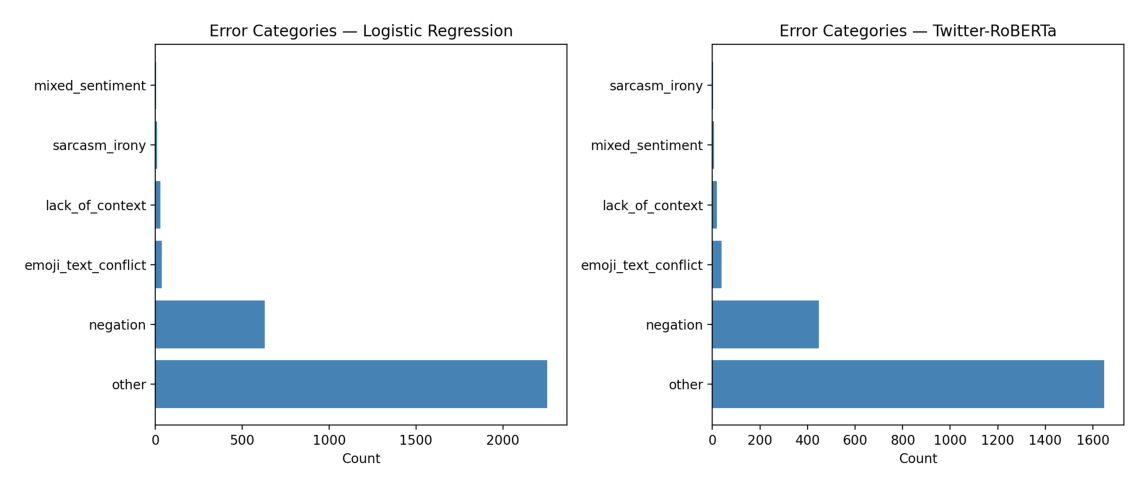

In [18]:
img = mpimg.imread(ROOT / "data/plots/error_category_distribution.png")
fig, ax = plt.subplots(figsize=(13, 5))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

In [19]:
# Sample misclassified examples per model
for model_result in error_data:
    print(f"\n{'='*70}")
    print(f"  {model_result['model']} — sample misclassifications (general test set)")
    print(f"{'='*70}")
    samples = pd.DataFrame(model_result["sample_errors"][:15])
    samples["error_category"] = samples["error_category"].str.replace("_", " ").str.title()
    display(samples[["error_category", "true_label", "predicted_label", "text"]].reset_index(drop=True))


  Logistic Regression — sample misclassifications (general test set)


,error_category,true_label,predicted_label,text
0,Other,neutral,positive,SASA will be having the first ever Bhangra Bootcamp on November 7th - 10pm at CIF! Only $5 to learn from our very ow...
1,Other,negative,neutral,Kim Jong Un executed another top military people for falling asleep.
2,Other,positive,neutral,Wale's content may have similarities to TPAB's but the difference is Kendrick executes it EXTREMELY better
3,Other,positive,neutral,Kim Kardashian is one stylish mama! The star of E!'s Keeping Up With the Kardashians announced Saturday morning that...
4,Other,negative,neutral,"""RT <USER> The guy is a nut, but I will miss Andy Rooney rambling about something ridiculous each Sunday night:"
5,Other,negative,neutral,Caltrain just can\u2019t catch a break. MT <USER> About 10:30 a.m. train 425 struck a female on the train tracks sou...
6,Negation,neutral,negative,Pretty soon I'll just do what the rest of the conservatives are doing and just not login anymore.
7,Negation,negative,neutral,"""Carly Fiorina isn't the 1st person 2 Xpose HillaryClinton as Corrupt Liar, but it seems the press only cares 2 give..."
8,Other,neutral,positive,Who wants to see Maya Rudolph sing Prince with my Thursday night
9,Negation,negative,neutral,"Mr Trump win without him, he can bring Confucius in the cabinet"



  Twitter-RoBERTa — sample misclassifications (general test set)


,error_category,true_label,predicted_label,text
0,Other,neutral,positive,SASA will be having the first ever Bhangra Bootcamp on November 7th - 10pm at CIF! Only $5 to learn from our very ow...
1,Negation,neutral,negative,Pretty soon I'll just do what the rest of the conservatives are doing and just not login anymore.
2,Other,neutral,positive,Who wants to see Maya Rudolph sing Prince with my Thursday night
3,Negation,negative,neutral,"Mr Trump win without him, he can bring Confucius in the cabinet"
4,Other,neutral,positive,"THANKSGIVING UPDATE: Tony Romo passes the turkey, intercepted by 86 yr old Grandma Jean"
5,Other,negative,neutral,"Also, rumor has it Maui Economic Chamber of Commerce was smooshing with Monsanto lunch in Friday. Hawaiian Politicia..."
6,Negation,neutral,negative,4th time I've cried today and it's surprisingly not about George Harrison
7,Other,neutral,positive,This Sales job might be a great fit for you: Prince George Career Open House: August 26th at 6 PM - cibc Hiring
8,Other,negative,neutral,\u2019No Favorites\u2019 for Russia-Portugal Clash - Capello: MOSCOW\u002c October 11 (RIA Novosti) - Russia\u2019s ...
9,Other,positive,neutral,"<USER> 1st day aftr elex Modi has got new CEA,Potatoe imports r on But folks see conspiracy everywhere"""


In [20]:
# Negation errors — most identifiable linguistic failure mode
print("Negation errors — examples where negation tripped up the model\n")
for model_result in error_data:
    neg_samples = [e for e in model_result["sample_errors"] if e["error_category"] == "negation"]
    if neg_samples:
        print(f"── {model_result['model']} ──")
        for e in neg_samples[:5]:
            print(f"  [{e['true_label']:8s} → {e['predicted_label']:8s}]  {e['text'][:110]}")
        print()

Negation errors — examples where negation tripped up the model

── Logistic Regression ──
  [neutral  → negative]  Pretty soon I'll just do what the rest of the conservatives are doing and just not login anymore.
  [negative → neutral ]  "Carly Fiorina isn't the 1st person 2 Xpose HillaryClinton as Corrupt Liar, but it seems the press only cares 
  [negative → neutral ]  Mr Trump win without him, he can bring Confucius in the cabinet

── Twitter-RoBERTa ──
  [neutral  → negative]  Pretty soon I'll just do what the rest of the conservatives are doing and just not login anymore.
  [negative → neutral ]  Mr Trump win without him, he can bring Confucius in the cabinet
  [neutral  → negative]  4th time I've cried today and it's surprisingly not about George Harrison
  [neutral  → negative]  <USER> MAC is perfect, but no longer animal-testing free 😿I'm on a constant search for a Lady Danger dupe that



## 9. Final Model Comparison Summary

In [ ]:
lr_gen  = eval_results["logistic_regression"]["general_test"]
lr_dom  = eval_results["logistic_regression"]["domain_shift_test"]
rob_gen = eval_results["twitter_roberta"]["general_test"]
rob_dom = eval_results["twitter_roberta"]["domain_shift_test"]

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy", "Macro F1", "Weighted F1",
        "Macro Precision", "Macro Recall",
        "Negative F1", "Neutral F1", "Positive F1",
    ],
    "LR — General": [
        lr_gen["accuracy"], lr_gen["macro"]["f1"], lr_gen["weighted"]["f1"],
        lr_gen["macro"]["precision"], lr_gen["macro"]["recall"],
        lr_gen["per_class"]["negative"]["f1"],
        lr_gen["per_class"]["neutral"]["f1"],
        lr_gen["per_class"]["positive"]["f1"],
    ],
    "LR — Domain Shift": [
        lr_dom["accuracy"], lr_dom["macro"]["f1"], lr_dom["weighted"]["f1"],
        lr_dom["macro"]["precision"], lr_dom["macro"]["recall"],
        lr_dom["per_class"]["negative"]["f1"],
        lr_dom["per_class"]["neutral"]["f1"],
        lr_dom["per_class"]["positive"]["f1"],
    ],
    "RoBERTa — General": [
        rob_gen["accuracy"], rob_gen["macro"]["f1"], rob_gen["weighted"]["f1"],
        rob_gen["macro"]["precision"], rob_gen["macro"]["recall"],
        rob_gen["per_class"]["negative"]["f1"],
        rob_gen["per_class"]["neutral"]["f1"],
        rob_gen["per_class"]["positive"]["f1"],
    ],
    "RoBERTa — Domain Shift": [
        rob_dom["accuracy"], rob_dom["macro"]["f1"], rob_dom["weighted"]["f1"],
        rob_dom["macro"]["precision"], rob_dom["macro"]["recall"],
        rob_dom["per_class"]["negative"]["f1"],
        rob_dom["per_class"]["neutral"]["f1"],
        rob_dom["per_class"]["positive"]["f1"],
    ],
}).set_index("Metric").round(4)

display(comparison)

In [ ]:
# Domain-shift performance drop
print("Performance drop: General Test → Domain Shift\n")
for col_gen, col_dom, name in [
    ("LR — General", "LR — Domain Shift", "Logistic Regression"),
    ("RoBERTa — General", "RoBERTa — Domain Shift", "Twitter-RoBERTa"),
]:
    drop = comparison[col_gen] - comparison[col_dom]
    print(f"{name}:")
    for metric, val in drop.items():
        bar = "▼" * max(0, int(abs(val) * 20))
        print(f"  {metric:<22}: Δ = -{val:.4f}  {bar}")
    print()

In [ ]:
# Final grouped bar chart
metrics_to_plot = ["Accuracy", "Macro F1", "Weighted F1"]
x = np.arange(len(metrics_to_plot))
width = 0.2
col_labels = ["LR — General", "LR — Domain Shift", "RoBERTa — General", "RoBERTa — Domain Shift"]
colors = ["#5a9dd4", "#a8d0e6", "#e07b54", "#f4c29c"]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (col, color) in enumerate(zip(col_labels, colors)):
    vals = [comparison.loc[m, col] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width, label=col, color=color)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Logistic Regression vs Twitter-RoBERTa — Key Metrics Comparison")
ax.legend(loc="lower right", fontsize=9)
ax.axhline(lr_gen["majority_baseline_accuracy"], color="grey", linestyle=":",
           linewidth=1.2, label="Majority baseline")
ax.grid(axis="y", linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

## 10. Conclusions

| Finding | Detail |
|---|---|
| **RoBERTa > Logistic Regression** | +8.9 pp accuracy, +0.118 macro F1 on general tweets. Contextual representations handle informal social-media language better than TF-IDF bag-of-words. |
| **Domain shift hurts both models** | ~24–28 pp accuracy drop for both models. Training on general tweets does not generalise to disaster-domain vocabulary. |
| **Positive class suffers most** | Positive-class recall drops from ~79% → ~16% (RoBERTa) under domain shift. Disaster tweets expressing gratitude or relief are linguistically distinct from general positive tweets. |
| **Negation is the top identifiable error** | 628 LR errors and 448 RoBERTa errors involve negation words. RoBERTa handles negation better overall (~25% fewer). |
| **Both models beat the majority baseline** | LR: 67.0% vs 45.9% baseline. RoBERTa: 75.9% vs 45.9% baseline. Both are learning real signal. |

### Limitations

- RoBERTa was fine-tuned on only 5,000 samples for 1 epoch due to CPU constraints. Full-dataset fine-tuning on GPU would likely improve results, especially domain-shift robustness.
- Domain-shift ground-truth labels are VADER-derived, not human-annotated. VADER is a validated tool for social media but is not equivalent to manual labeling.
- Error categories are rule-based heuristics, not verified by human judges. The "other" category (majority of errors) reflects the limits of keyword-based analysis.